In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the master file
df = pd.read_csv("facies_vectors.csv")

In [3]:
# 1. Check for NaN values per log curve
print("Missing values per curve:")
print(df.isnull().sum())

Missing values per curve:
Facies         0
Formation      0
Well Name      0
Depth          0
GR             0
ILD_log10      0
DeltaPHI       0
PHIND          0
PE           917
NM_M           0
RELPOS         0
dtype: int64


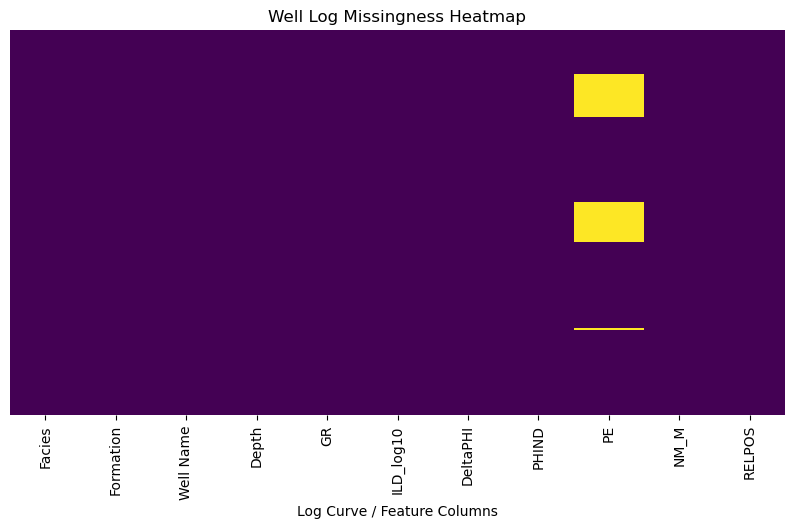

In [4]:
# 2. Visualize missingness as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Well Log Missingness Heatmap")
plt.xlabel("Log Curve / Feature Columns")
plt.show()

C:\Users\pragy\AppData\Local\Temp\ipykernel_28020\2228266695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Facies', palette='Set2')


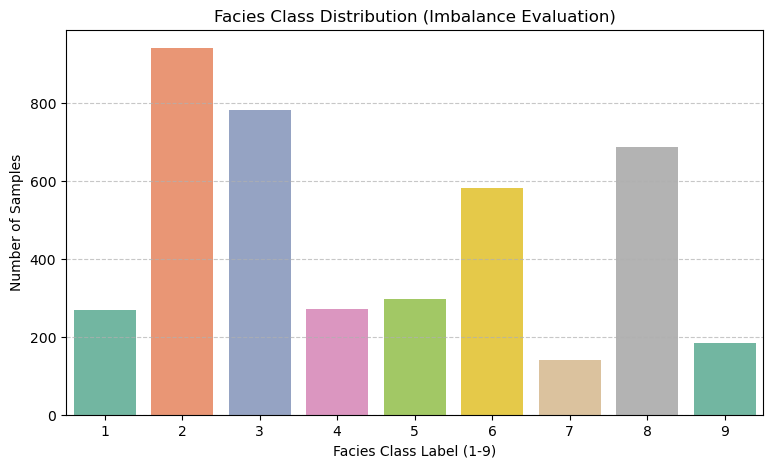


Exact Facies Counts:
Facies
1    268
2    940
3    780
4    271
5    296
6    582
7    141
8    686
9    185
Name: count, dtype: int64


In [5]:
# Count class distribution
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Facies', palette='Set2')
plt.title("Facies Class Distribution (Imbalance Evaluation)")
plt.xlabel("Facies Class Label (1-9)")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nExact Facies Counts:")
print(df['Facies'].value_counts().sort_index())

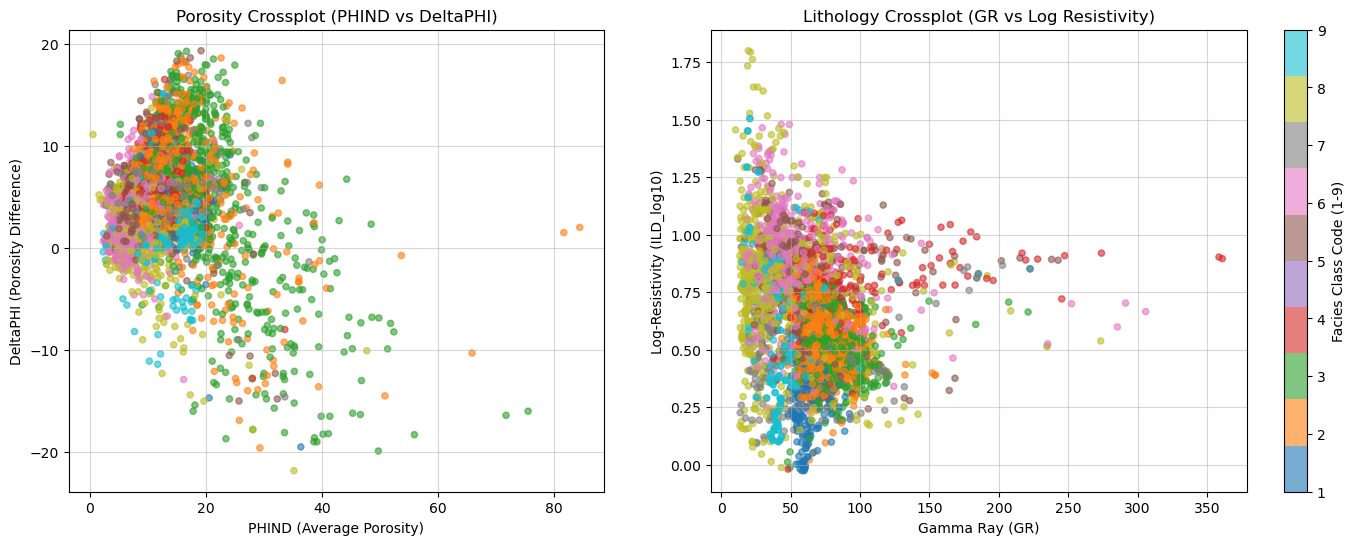

In [6]:
# Set up a 1x2 grid of crossplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Porosity Crossplot (PHIND vs DeltaPHI)
scatter1 = ax[0].scatter(df['PHIND'], df['DeltaPHI'], c=df['Facies'], cmap='tab10', alpha=0.6, s=20)
ax[0].set_title("Porosity Crossplot (PHIND vs DeltaPHI)")
ax[0].set_xlabel("PHIND (Average Porosity)")
ax[0].set_ylabel("DeltaPHI (Porosity Difference)")
ax[0].grid(True, alpha=0.5)

# Plot 2: Lithology vs Fluid Crossplot (GR vs ILD_log10)
scatter2 = ax[1].scatter(df['GR'], df['ILD_log10'], c=df['Facies'], cmap='tab10', alpha=0.6, s=20)
ax[1].set_title("Lithology Crossplot (GR vs Log Resistivity)")
ax[1].set_xlabel("Gamma Ray (GR)")
ax[1].set_ylabel("Log-Resistivity (ILD_log10)")
ax[1].grid(True, alpha=0.5)

# Add colorbar to identify the Facies integers
cbar = fig.colorbar(scatter2, ax=ax, orientation='vertical', fraction=0.02, pad=0.03)
cbar.set_label('Facies Class Code (1-9)')

plt.show()

In [7]:
# Clean missing values using the local median of each specific well
df['PE'] = df.groupby('Well Name')['PE'].transform(lambda x: x.fillna(x.median()))

# Confirm there are absolutely zero remaining missing values across the dataset
print("Missing values count post-imputation:")
print(df.isnull().sum())

Missing values count post-imputation:
Facies         0
Formation      0
Well Name      0
Depth          0
GR             0
ILD_log10      0
DeltaPHI       0
PHIND          0
PE           905
NM_M           0
RELPOS         0
dtype: int64


In [8]:
# Fallback: Fill the remaining rows (from the well completely missing PE) with the overall dataset median
df['PE'] = df['PE'].fillna(df['PE'].median())

# Re-verify that there are absolutely zero missing values remaining
print("Missing values count after global fallback:")
print(df.isnull().sum())

Missing values count after global fallback:
Facies       0
Formation    0
Well Name    0
Depth        0
GR           0
ILD_log10    0
DeltaPHI     0
PHIND        0
PE           0
NM_M         0
RELPOS       0
dtype: int64


In [9]:
# 1. Create a lithology-porosity ratio proxy using Gamma Ray and Average Porosity
df['GR_PHIND_ratio'] = df['GR'] / (df['PHIND'] + 0.001)

# 2. Compute a rolling mean and standard deviation over a 3-sample window per well
# We group by well name so the depth sequence of one well doesn't bleed into another!
core_curves = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

for curve in core_curves:
    df[f'{curve}_roll_mean'] = df.groupby('Well Name')[curve].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    df[f'{curve}_roll_std'] = df.groupby('Well Name')[curve].transform(lambda x: x.rolling(window=3, min_periods=1).std().fillna(0))

print("Feature engineering complete.")
print("Current total dataframe shape:", df.shape)

Feature engineering complete.
Current total dataframe shape: (4149, 22)


In [10]:
from sklearn.model_selection import train_test_split

# Separate the model features from target labels and descriptive metadata
metadata = ['Facies', 'Formation', 'Well Name', 'Depth']
features = [col for col in df.columns if col not in metadata]

X = df[features]
y = df['Facies']

# Split 1: Extract 70% for training and retain 30% for a temporary pool
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split 2: Divide that 30% pool evenly to get 15% Validation and 15% Test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Features dimension (X): {X.shape[1]} columns")
# Print row counts to verify exact matrix splits
print(f"Train size: {X_train.shape[0]} samples")
print(f"Val size:   {X_val.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Features dimension (X): 18 columns
Train size: 2904 samples
Val size:   622 samples
Test size:  623 samples


In [11]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Initialize and train the scaler solely on the training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Normalize validation and test features using the training baseline rules
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 3. Save the scaler object to disk for later use
joblib.dump(scaler, 'scaler.joblib')

print("Scaler successfully saved to disk as 'scaler.joblib'.")
print("Scaled Train Mean (First 3 features):", np.round(X_train_scaled.mean(axis=0)[:3], 2))
print("Scaled Train Std  (First 3 features):", np.round(X_train_scaled.std(axis=0)[:3], 2))

Scaler successfully saved to disk as 'scaler.joblib'.
Scaled Train Mean (First 3 features): [ 0. -0.  0.]
Scaled Train Std  (First 3 features): [1. 1. 1.]


In [12]:
# Convert scaled numpy arrays back to DataFrames for easy CSV exportation
pd.DataFrame(X_train_scaled, columns=features).to_csv('X_train_clean.csv', index=False)
pd.DataFrame(X_val_scaled, columns=features).to_csv('X_val_clean.csv', index=False)
pd.DataFrame(X_test_scaled, columns=features).to_csv('X_test_clean.csv', index=False)

# Save the target labels 
pd.DataFrame(y_train, columns=['Facies']).to_csv('y_train.csv', index=False)
pd.DataFrame(y_val, columns=['Facies']).to_csv('y_val.csv', index=False)
pd.DataFrame(y_test, columns=['Facies']).to_csv('y_test.csv', index=False)

print("PREPROCESSING COMPLETE: Checkpoints successfully saved!")

PREPROCESSING COMPLETE: Checkpoints successfully saved!


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Initialize the base Random Forest model
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Define the tuning grid for tree depth and count
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20]
}

# 3. Run Grid Search using your scaled training data
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print("Best Random Forest Parameters:", rf_grid.best_params_)

Best Random Forest Parameters: {'max_depth': 20, 'n_estimators': 150}


In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# XGBoost strictly requires 0-indexed classes (0-8 instead of 1-9)
y_train_xgb = y_train.values.ravel() - 1
y_val_xgb = y_val.values.ravel() - 1

# Initialize base XGBoost for multi-class classification
xgb_base = XGBClassifier(objective='multi:softprob', num_class=9, random_state=42)

# Define the tuning grid
xgb_param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8]
}

# Execute the Grid Search
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train_xgb)

best_xgb = xgb_grid.best_estimator_
print("Best XGBoost Parameters:", xgb_grid.best_params_)

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 8}


Random Forest Validation Accuracy: 0.7379
XGBoost Validation Accuracy:       0.7476


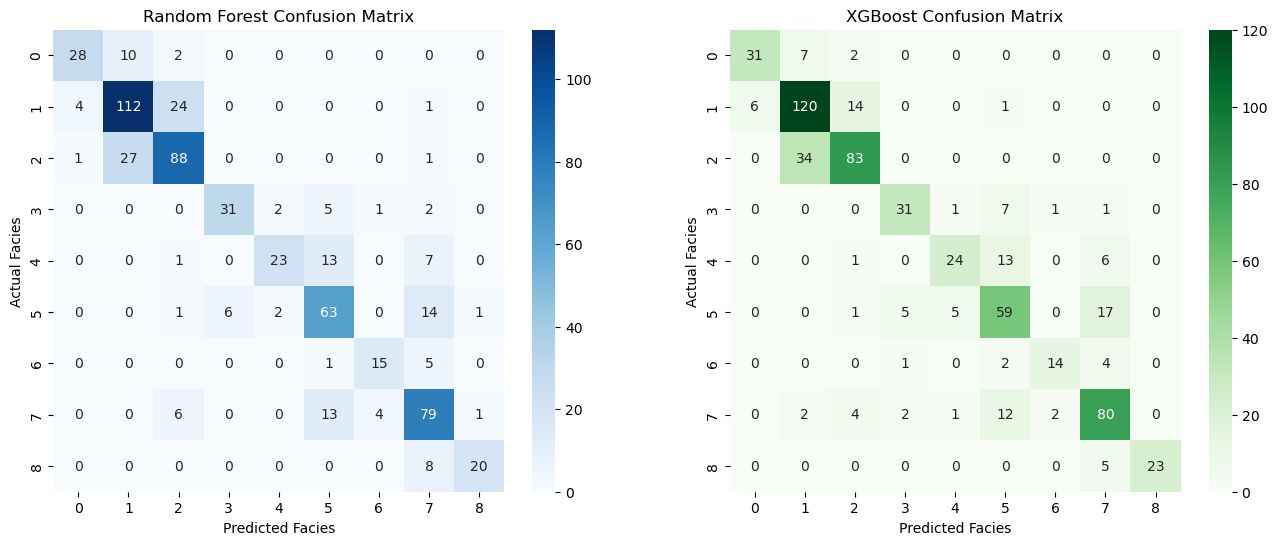


--- Detailed Classification Report (Random Forest) ---
              precision    recall  f1-score   support

           1       0.85      0.70      0.77        40
           2       0.75      0.79      0.77       141
           3       0.72      0.75      0.74       117
           4       0.84      0.76      0.79        41
           5       0.85      0.52      0.65        44
           6       0.66      0.72      0.69        87
           7       0.75      0.71      0.73        21
           8       0.68      0.77      0.72       103
           9       0.91      0.71      0.80        28

    accuracy                           0.74       622
   macro avg       0.78      0.72      0.74       622
weighted avg       0.75      0.74      0.74       622



In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions on validation data
rf_preds = best_rf.predict(X_val_scaled)
xgb_preds = best_xgb.predict(X_val_scaled) + 1 # Add 1 to shift back to the 1-9 scale

# 2. Print high-level metrics summary
print(f"Random Forest Validation Accuracy: {accuracy_score(y_val, rf_preds):.4f}")
print(f"XGBoost Validation Accuracy:       {accuracy_score(y_val, xgb_preds):.4f}")

# 3. Plot side-by-side Confusion Matrix Heatmaps
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_val, rf_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Random Forest Confusion Matrix")
ax[0].set_xlabel("Predicted Facies")
ax[0].set_ylabel("Actual Facies")

sns.heatmap(confusion_matrix(y_val, xgb_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("XGBoost Confusion Matrix")
ax[1].set_xlabel("Predicted Facies")
ax[1].set_ylabel("Actual Facies")

plt.show()

# 4. Print the comprehensive classification report for your top baseline model
print("\n--- Detailed Classification Report (Random Forest) ---")
print(classification_report(y_val, rf_preds))

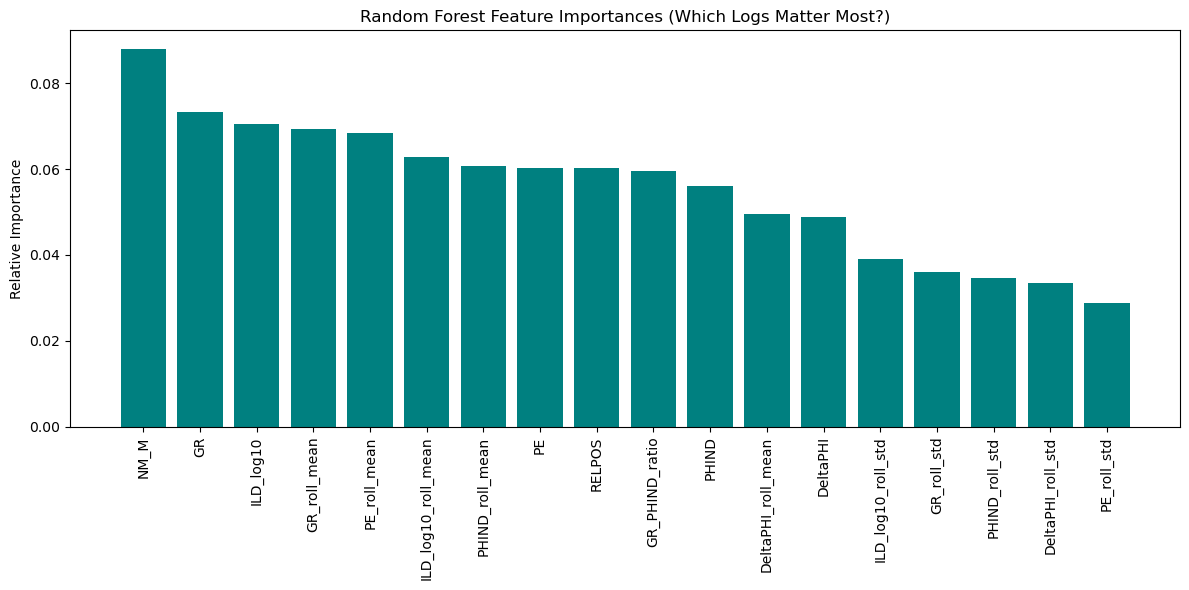

BASELINE MODELS COMPLETE: Saved successfully as 'best_baseline_rf.joblib'.


In [16]:
import joblib

# 1. Calculate and sort feature importances from your optimized Random Forest
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. Plot the relative importance values
plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importances (Which Logs Matter Most?)")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X_train_scaled.shape[1]), [features[i] for i in indices], rotation=90)
plt.ylabel("Relative Importance")
plt.tight_layout()
plt.show()

# 3. Save your best model checkpoint to disk
joblib.dump(best_rf, 'best_baseline_rf.joblib')
print("BASELINE MODELS COMPLETE: Saved successfully as 'best_baseline_rf.joblib'.")

In [17]:
# 1. Reload the master dataframe and use the saved scaler to normalize features
scaler = joblib.load('scaler.joblib')
metadata_cols = ['Facies', 'Formation', 'Well Name', 'Depth']
feature_cols = [col for col in df.columns if col not in metadata_cols]

# 2. Build continuous 3D windows strictly within individual wells
X_seq, y_seq = [], []
window_size = 5
half_w = window_size // 2

for well in df['Well Name'].unique():
    well_df = df[df['Well Name'] == well].copy()
    # Scale features using the baseline pipeline configuration
    scaled_features = scaler.transform(well_df[feature_cols])
    labels = well_df['Facies'].values - 1 # 0-indexed for the neural network
    
    for i in range(half_w, len(well_df) - half_w):
        X_seq.append(scaled_features[i - half_w : i + half_w + 1])
        y_seq.append(labels[i])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# 3. Stratify split the sequence structures into 70% Train, 15% Val, 15% Test
X_train_cnn, X_temp, y_train_cnn, y_temp = train_test_split(X_seq, y_seq, test_size=0.30, random_state=42, stratify=y_seq)
X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"CNN Train Shape: {X_train_cnn.shape}")
print(f"CNN Val Shape:   {X_val_cnn.shape}")

CNN Train Shape: (2876, 5, 18)
CNN Val Shape:   (616, 5, 18)


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Construct the sequence-aware network structure
model = models.Sequential([
    layers.Input(shape=(window_size, len(feature_cols))),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(9, activation='softmax') # 9 output classes for our 9 facies
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 5, 32)               │           1,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 5, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │             297 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,345 (40.41 KB)

 Trainable params: 10,345 (40.41 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculate class weights based on the distribution of training targets
unique_classes = np.unique(y_train_cnn)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_cnn)
class_weight_dict = dict(zip(unique_classes, weights))

# 2. Train the CNN model
history = model.fit(
    X_train_cnn, y_train_cnn, 
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=15, 
    batch_size=32, 
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3209 - loss: 1.6794 - val_accuracy: 0.4529 - val_loss: 1.3433
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5198 - loss: 1.1179 - val_accuracy: 0.5357 - val_loss: 1.1288
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5549 - loss: 1.0114 - val_accuracy: 0.5552 - val_loss: 1.0795
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5598 - loss: 0.9634 - val_accuracy: 0.5974 - val_loss: 1.0192
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5737 - loss: 0.9209 - val_accuracy: 0.5974 - val_loss: 0.9933
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5873 - loss: 0.8818 - val_accuracy: 0.6039 - val_loss: 0.9620
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5974 - loss: 0.8496 - val_accuracy: 0.6023 - val_loss: 0.9908
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6026 - loss: 0.8202 - val_accuracy: 0.6120 - val_l

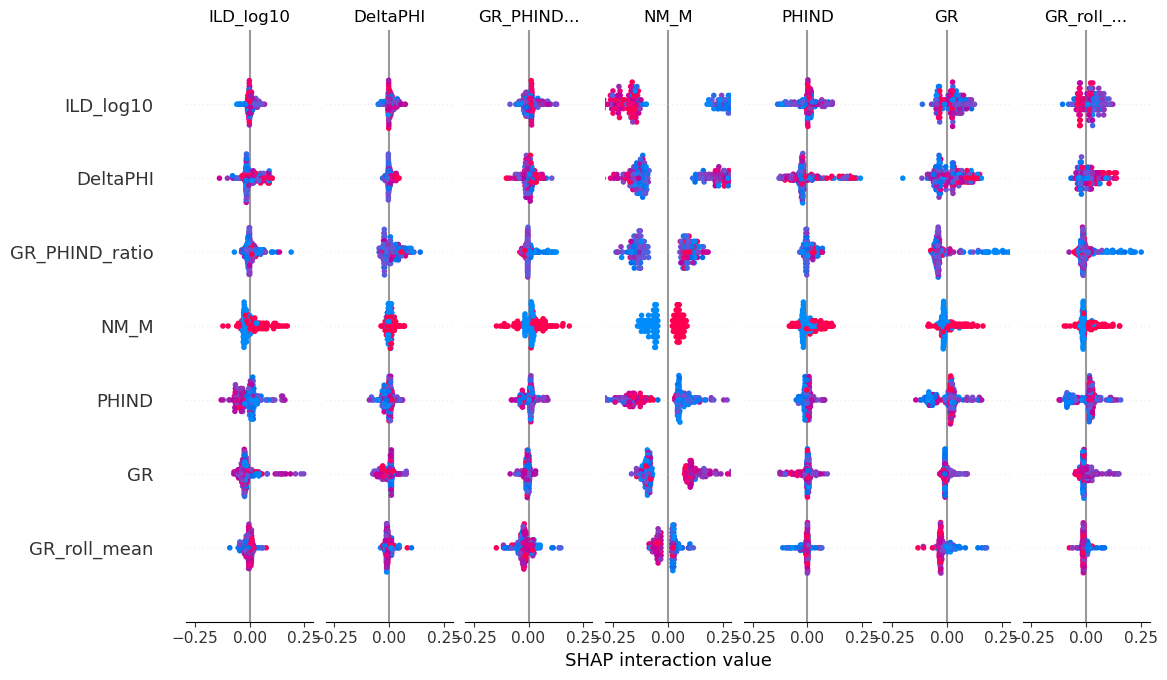

In [20]:
import shap

# 1. Initialize the SHAP tree explainer using your optimized random forest checkpoint
explainer = shap.TreeExplainer(best_rf)

# 2. Compute SHAP values on a subset of validation features for speed efficiency
shap_values = explainer.shap_values(X_val_scaled[:200])

# 3. Generate the summary plot showing feature contributions
shap.summary_plot(shap_values, X_val_scaled[:200], feature_names=features)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


================ FINAL TEST SET PERFORMANCE ================
Final Test Accuracy: 0.6966

Final Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.72      0.78        40
           2       0.72      0.79      0.76       141
           3       0.75      0.74      0.74       117
           4       0.73      0.75      0.74        40
           5       0.80      0.27      0.40        45
           6       0.53      0.67      0.59        88
           7       0.71      0.57      0.63        21
           8       0.65      0.70      0.67       103
           9       0.92      0.79      0.85        28

    accuracy                           0.70       623
   macro avg       0.74      0.67      0.69       623
weighted avg       0.71      0.70      0.69       623



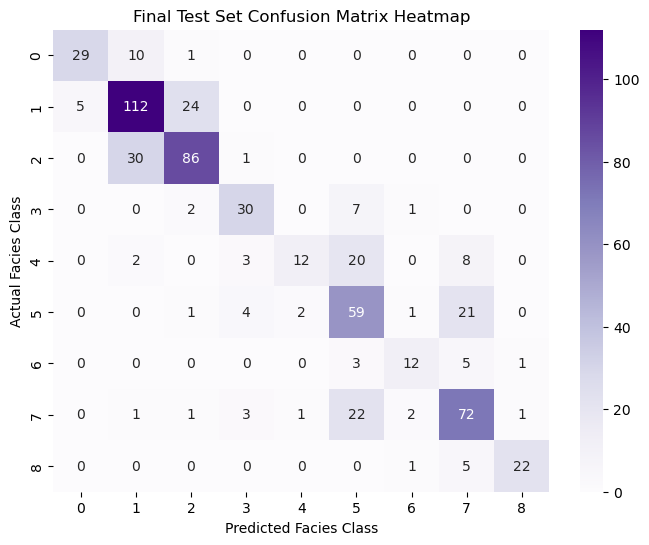

In [21]:
# 1. Load your pristine test dataset checkpoints
X_test = pd.read_csv('X_test_clean.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

# 2. Load your top-performing saved baseline model
best_model = joblib.load('best_baseline_rf.joblib')

# 3. Generate final test predictions
final_preds = best_model.predict(X_test)

# 4. Print your final portfolio scoreboard metrics
print("================ FINAL TEST SET PERFORMANCE ================")
print(f"Final Test Accuracy: {accuracy_score(y_test, final_preds):.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test, final_preds))

# 5. Generate a final confusion matrix heatmap for your report
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Purples')
plt.title("Final Test Set Confusion Matrix Heatmap")
plt.xlabel("Predicted Facies Class")
plt.ylabel("Actual Facies Class")
plt.show()

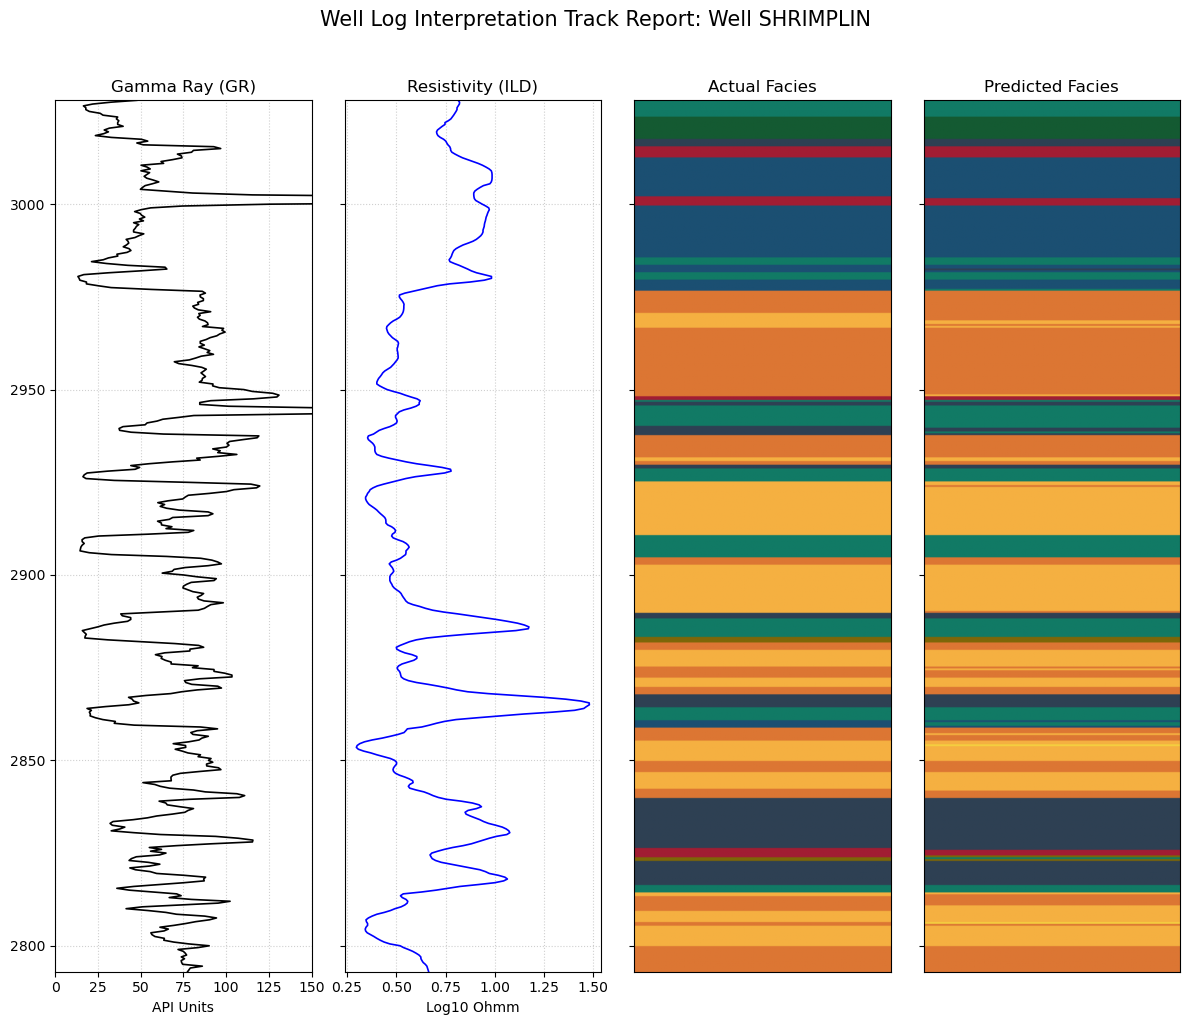

In [23]:
import matplotlib.colors as colors

# 1. Select a continuous well to visualize (e.g., 'SHRIMPLIN')
well_name_to_plot = 'SHRIMPLIN'
well_data = df[df['Well Name'] == well_name_to_plot].sort_values('Depth')

# 2. Extract and scale features matching your exact pipeline configuration
X_well_raw = well_data[features]
X_well_scaled = scaler.transform(X_well_raw)

# 3. Predict the facies column down the continuous depth profile
well_data['Pred_Facies'] = best_rf.predict(X_well_scaled)

# 4. Establish a standard discrete lithology colormap for the 9 facies
facies_colors = ['#F4D03F', '#F5B041', '#DC7633', '#A11D33', '#1B4F72', '#2E4053', '#7D6608', '#117A65', '#145A32']
cmap_facies = colors.ListedColormap(facies_colors, 'indexed')

# 5. Set up a 4-column track layout
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 10), sharey=True)

# Track 1: Gamma Ray (GR) Log Curve
ax[0].plot(well_data['GR'], well_data['Depth'], color='black', lw=1.2)
ax[0].set_title("Gamma Ray (GR)")
ax[0].set_xlabel("API Units")
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].set_xlim(0, 150)

# Track 2: Resistivity (ILD_log10) Log Curve
ax[1].plot(well_data['ILD_log10'], well_data['Depth'], color='blue', lw=1.2)
ax[1].set_title("Resistivity (ILD)")
ax[1].set_xlabel("Log10 Ohmm")
ax[1].grid(True, linestyle=':', alpha=0.6)

# Track 3: Actual Facies Column (Lithology Strip)
actual_strip = np.repeat(well_data['Facies'].values, 100).reshape(-1, 100)
ax[2].imshow(actual_strip, cmap=cmap_facies, aspect='auto', 
              extent=[0, 20, well_data['Depth'].max(), well_data['Depth'].min()], vmin=1, vmax=9)
ax[2].set_title("Actual Facies")
ax[2].set_xticks([])

# Track 4: Predicted Facies Column (Model Strip)
pred_strip = np.repeat(well_data['Pred_Facies'].values, 100).reshape(-1, 100)
ax[3].imshow(pred_strip, cmap=cmap_facies, aspect='auto', 
              extent=[0, 20, well_data['Depth'].max(), well_data['Depth'].min()], vmin=1, vmax=9)
ax[3].set_title("Predicted Facies")
ax[3].set_xticks([])

# Invert the Y-axis globally because geological depths increase downward
ax[0].invert_yaxis()

plt.suptitle(f"Well Log Interpretation Track Report: Well {well_name_to_plot}", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()